In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv('./data/HistoricalData_1730736171966.csv')

# only keep the columns we need
df = df[['Date', 'Close/Last']]

df.columns = ['ds', 'y']
df.head()

,ds,y
0,11/01/2024,524.94
1,10/31/2024,522.67
2,10/30/2024,533.16
3,10/29/2024,534.77
4,10/28/2024,533.92


In [10]:
# remove any NaN or other values
df = df.dropna()

# remove values in Y where there is a .
df = df[df['y'] != '.']
df.head()

,ds,y
0,11/01/2024,524.94
1,10/31/2024,522.67
2,10/30/2024,533.16
3,10/29/2024,534.77
4,10/28/2024,533.92


In [11]:
m = Prophet()
m.fit(df)

from prophet.serialize import model_to_json, model_from_json
with open('serialized_model.json', 'w') as fout:
    fout.write(model_to_json(m))  # Save model

09:06:18 - cmdstanpy - INFO - Chain [1] start processing
09:06:19 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
2876,2025-10-28
2877,2025-10-29
2878,2025-10-30
2879,2025-10-31
2880,2025-11-01


In [13]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2876,2025-10-28,607.150606,554.520287,663.893315
2877,2025-10-29,607.410969,555.883752,662.251583
2878,2025-10-30,607.789698,552.773341,664.830547
2879,2025-10-31,608.222351,554.259573,664.779739
2880,2025-11-01,604.922402,550.330674,660.262403


/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


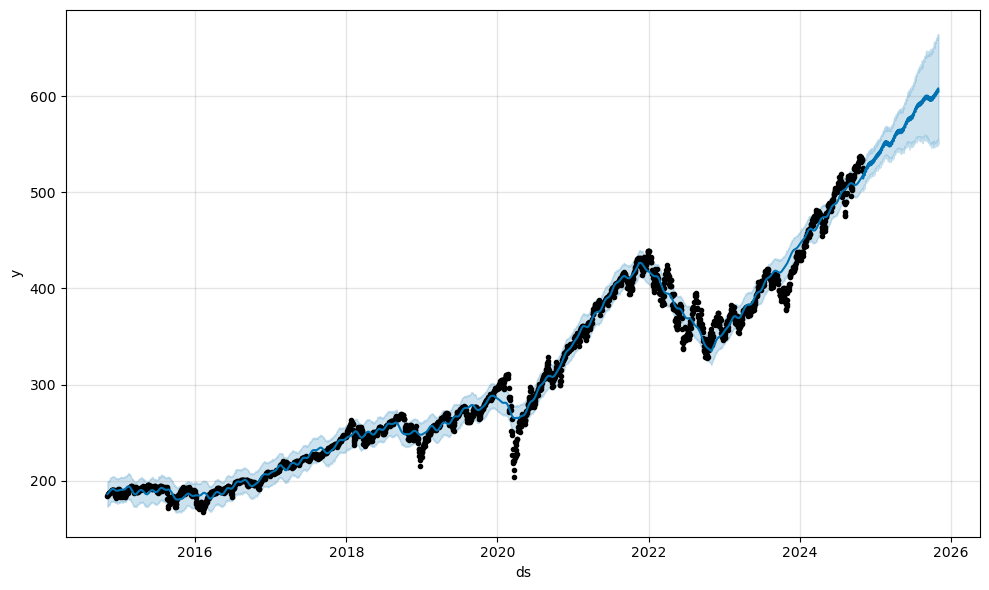

In [14]:
fig1 = m.plot(forecast)

/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of 

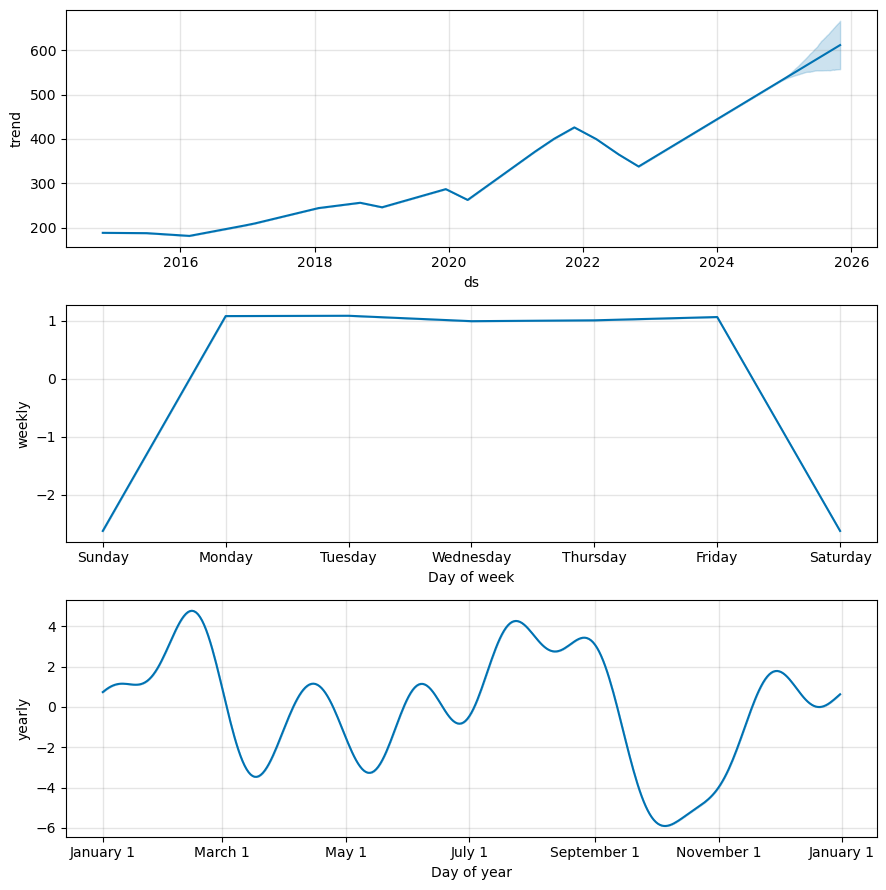

In [15]:

fig2 = m.plot_components(forecast)

In [16]:
from prophet.plot import plot_plotly
import plotly.graph_objs as go
print(go)

plot_plotly(m, forecast)

<module 'plotly.graph_objs' from '/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/plotly/graph_objs/__init__.py'>


In [17]:
future = m.make_future_dataframe(periods=1826)
future['cap'] = 8.5
fcst = m.predict(future)
fcst

,ds,trend,cap,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-11-04,188.556400,8.5,172.455778,198.058070,188.556400,188.556400,-2.451686,-2.451686,-2.451686,1.088578,1.088578,1.088578,-3.540264,-3.540264,-3.540264,0.0,0.0,0.0,186.104714
1,2014-11-05,188.553884,8.5,173.724569,199.018524,188.553884,188.553884,-2.351757,-2.351757,-2.351757,0.995276,0.995276,0.995276,-3.347032,-3.347032,-3.347032,0.0,0.0,0.0,186.202127
2,2014-11-06,188.551368,8.5,173.791688,198.863419,188.551368,188.551368,-2.129121,-2.129121,-2.129121,1.009888,1.009888,1.009888,-3.139009,-3.139009,-3.139009,0.0,0.0,0.0,186.422247
3,2014-11-07,188.548852,8.5,173.731703,199.521647,188.548852,188.548852,-1.849890,-1.849890,-1.849890,1.066730,1.066730,1.066730,-2.916621,-2.916621,-2.916621,0.0,0.0,0.0,186.698962
4,2014-11-10,188.541304,8.5,174.047976,200.590898,188.541304,188.541304,-1.089259,-1.089259,-1.089259,1.083173,1.083173,1.083173,-2.172432,-2.172432,-2.172432,0.0,0.0,0.0,187.452045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4337,2029-10-28,974.895733,8.5,335.472556,1636.653348,337.611379,1642.466181,-7.102060,-7.102060,-7.102060,-2.621824,-2.621824,-2.621824,-4.480236,-4.480236,-4.480236,0.0,0.0,0.0,967.793673
4338,2029-10-29,975.145120,8.5,336.568517,1641.905970,337.060797,1643.280653,-3.292784,-3.292784,-3.292784,1.083173,1.083173,1.083173,-4.375957,-4.375957,-4.375957,0.0,0.0,0.0,971.852335
4339,2029-10-30,975.394506,8.5,327.532998,1643.314581,336.568052,1644.095125,-3.172650,-3.172650,-3.172650,1.088578,1.088578,1.088578,-4.261228,-4.261228,-4.261228,0.0,0.0,0.0,972.221856
4340,2029-10-31,975.643892,8.5,334.366952,1645.526932,336.075307,1644.909597,-3.139527,-3.139527,-3.139527,0.995276,0.995276,0.995276,-4.134803,-4.134803,-4.134803,0.0,0.0,0.0,972.504365


<class 'matplotlib.figure.Figure'>


/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/opt/anaconda3/envs/skbio-dev/lib/python3.12/site-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



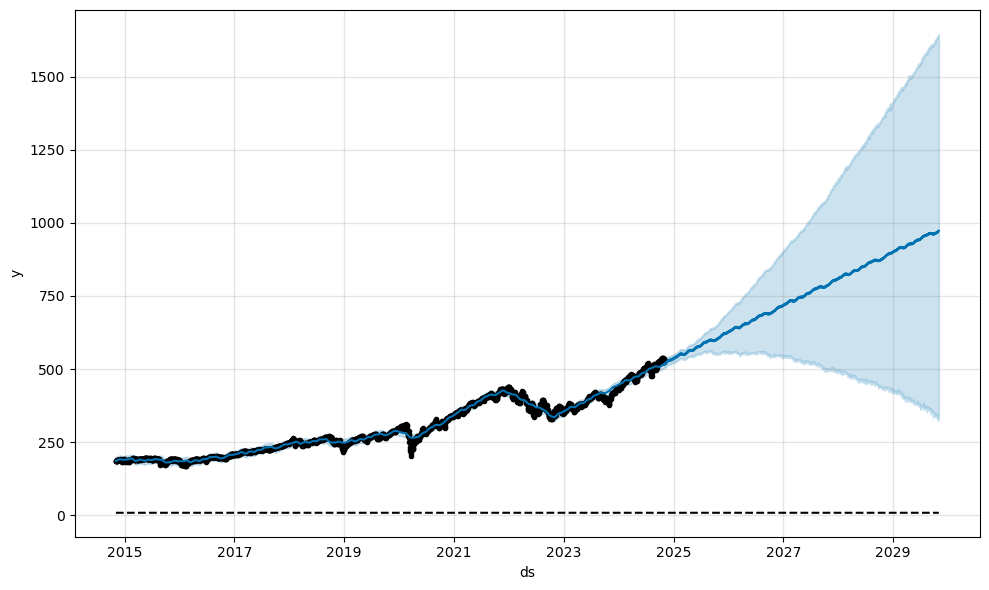

In [18]:
fig = m.plot(fcst)
print(type(fig))

In [19]:
# get yhat from fcst where ds is between 2024-08-10 and 2024-08-30
from math import floor

start = '2024-08-01'
end = '2024-10-30'

fy2024 = fcst[(fcst['ds'] > start) & (fcst['ds'] < end)][['ds', 'yhat']]

# get lowest in fy2024 along with date
low = fy2024[fy2024['yhat'] == fy2024['yhat'].min()]

# get max in fy2024 along with date
high = fy2024[fy2024['yhat'] == fy2024['yhat'].max()]

print(low)
print(high)

low_p = floor(list(low["yhat"])[0])
high_p = list(high["yhat"])[0]

amt = 10
print("Current Amount (USD): ", amt)

print(f"Amount on {str(low['ds'].values[0])[:10]}: INR", amt*low_p)
print("Saving: INR", (amt*high_p - amt*low_p))

print(((high_p-low_p)/low_p)*100)

             ds        yhat
2451 2024-08-02  502.390858
             ds        yhat
2512 2024-10-29  516.505903
Current Amount (USD):  10
Amount on 2024-08-02: INR 5020
Saving: INR 145.05903021513495
2.8896221158393463


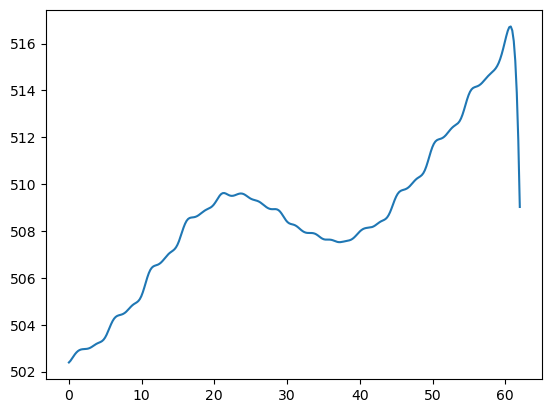

In [20]:
# plot a figure with only data from start to end
rel = (fcst[(fcst['ds'] > start) & (fcst['ds'] < end)])

prices = rel['yhat']
dates = rel['ds']

from scipy.interpolate import make_interp_spline, BSpline
xnew = np.linspace(0, len(prices), 300)
spl = make_interp_spline(range(len(prices)), prices, k=5)
y_smooth = spl(xnew)
plt.plot(xnew, y_smooth)
plt.savefig('rel.png')